# 📊 KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU (EDA)
**Mục tiêu của Notebook này:** Phân tích trực quan các vấn đề của bộ dữ liệu thô (Missing Values, Outliers) để làm cơ sở cho việc xây dựng class `DataPreprocessor` ở các bước tiếp theo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
df_train = pd.read_csv("data/train.csv")
os.makedirs("reports", exist_ok=True)
print(">>> Nạp dữ liệu thành công. Kích thước tập Train:", df_train.shape)

### 1. Phân tích Dữ liệu thiếu (Missing Values)
Rất nhiều cột trong bộ dữ liệu này bị thiếu. Tuy nhiên, theo từ điển dữ liệu (Data Dictionary), các khoảng trắng ở cột `PoolQC`, `Alley`, `Fence` mang ý nghĩa là "Không tồn tại" chứ không phải lỗi nhập liệu.

In [ ]:
plt.figure(figsize=(12, 6))
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df_train)) * 100
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette="Reds_r")
plt.title(
    "Tỷ lệ phần trăm Dữ liệu bị thiếu (Missing Values) theo Cột",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Phần trăm thiếu (%)", fontsize=12)
plt.xlabel("Tên Cột (Features)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig("reports/04_missing_values.png", dpi=300)
plt.show()

### 2. Phân tích Ngoại lai (Outliers) đối với biến Diện tích
Diện tích sống trên mặt đất (`GrLivArea`) là biến có tương quan mạnh nhất với giá nhà. Tuy nhiên, biểu đồ Scatter dưới đây cho thấy có những dữ liệu dị thường làm sai lệch thuật toán tuyến tính.

>>> Đang nạp lại dữ liệu train.csv...


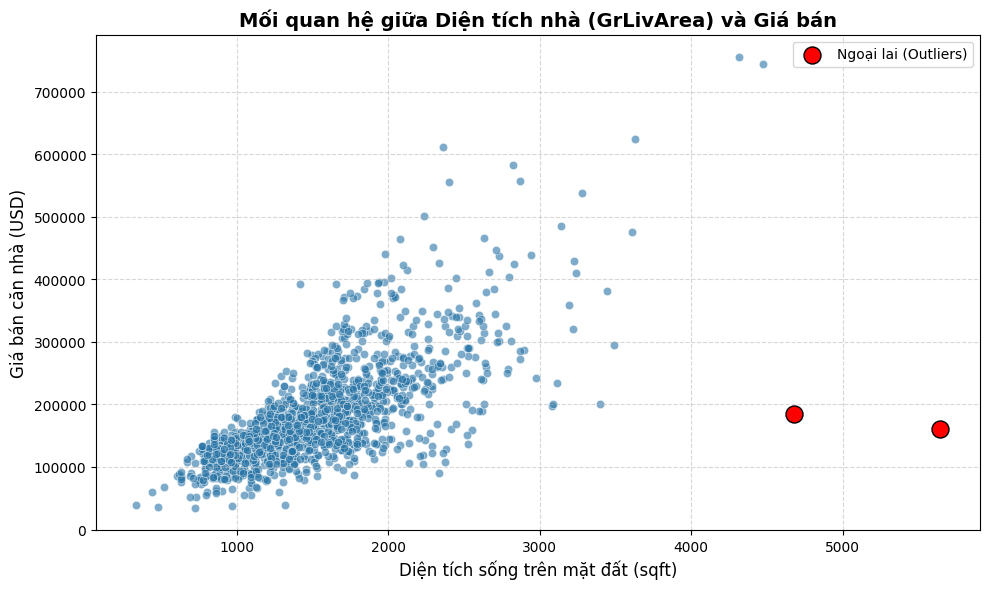

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
if "df_train" not in locals():
    print(">>> Đang nạp lại dữ liệu train.csv...")
    df_train = pd.read_csv("data/train.csv")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_train["GrLivArea"], y=df_train["SalePrice"], alpha=0.6, color="#2874A6"
)

outliers = df_train[(df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)]
plt.scatter(
    x=outliers["GrLivArea"],
    y=outliers["SalePrice"],
    color="red",
    s=150,
    edgecolor="black",
    label="Ngoại lai (Outliers)",
)

plt.title(
    "Mối quan hệ giữa Diện tích nhà (GrLivArea) và Giá bán",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Diện tích sống trên mặt đất (sqft)", fontsize=12)
plt.ylabel("Giá bán căn nhà (USD)", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/05_outliers_scatter.png", dpi=300)
plt.show()